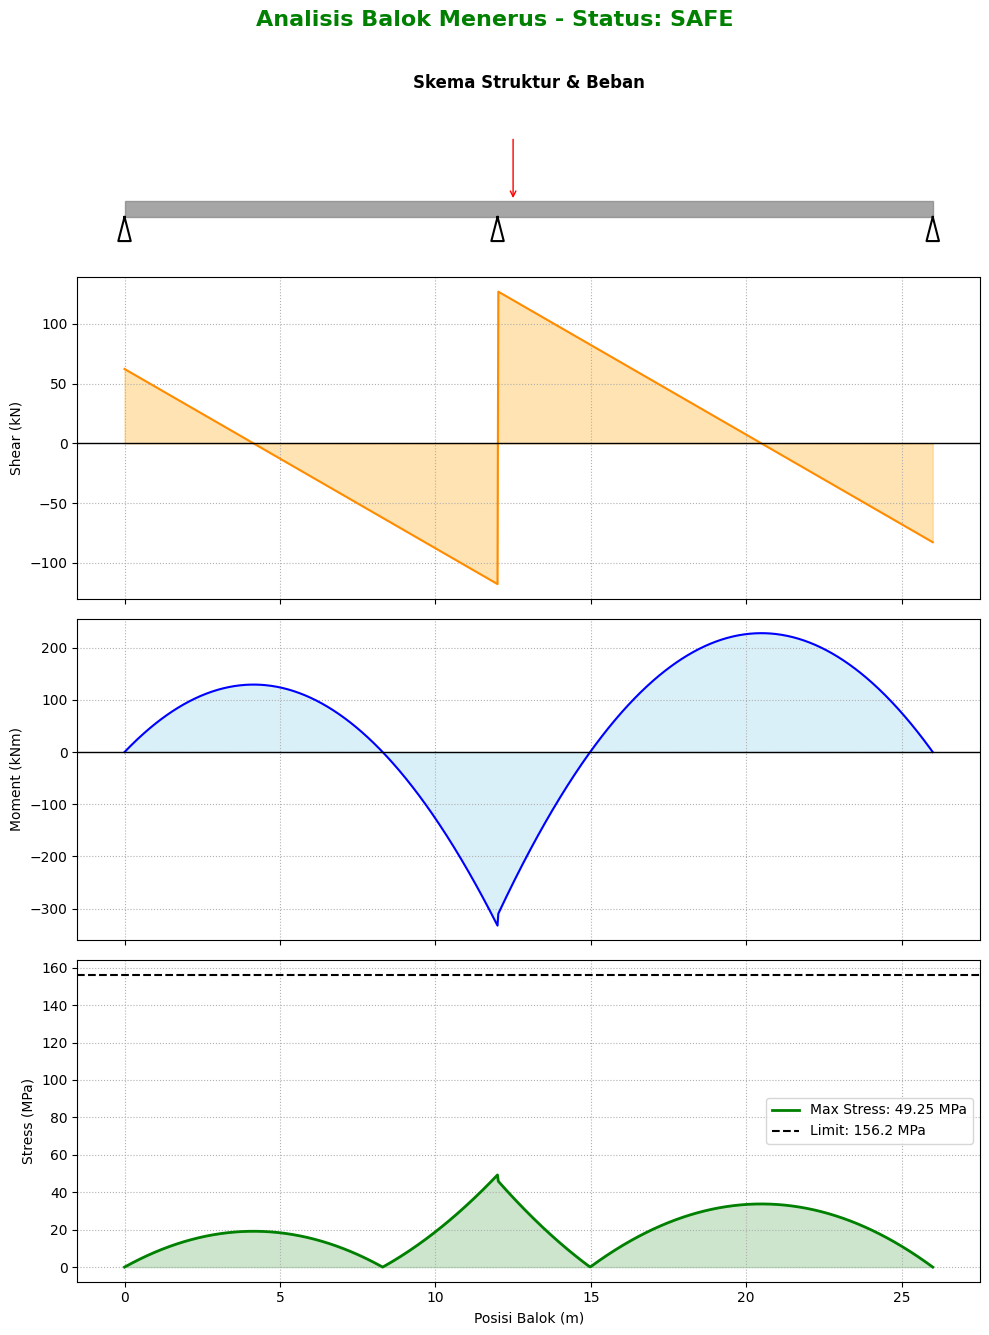

--- LAPORAN KEAMANAN ---
Tegangan Maksimum Terjadi: 49.25 MPa
Batas Tegangan Ijin: 156.25 MPa
Status: SAFE


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Parameter Input & Material
L1, L2 = 12, 14
total_L = L1 + L2
w, P, a = 15.0, 40.0, 12.5 # Beban ditingkatkan untuk tes keamanan
b, h = 0.2, 0.45          # Dimensi balok (m)
I = (1/12) * b * (h**3)

# Properti Keamanan
yield_strength = 250      # MPa (Baja umum)
safety_factor = 1.6
sigma_allowable = yield_strength / safety_factor

# 2. Kalkulasi Statika (3 Tumpuan)
term_udl = -(w * L1**3 / 4) - (w * L2**3 / 4)
term_point = -(P * a / L1) * (L1**2 - a**2)
Mb = (term_udl + term_point) / (2 * (L1 + L2))

Ra = (w * L1 / 2) + (P * (L1 - a) / L1) + (Mb / L1)
Rc = (w * L2 / 2) + (Mb / L2)
Rb = (w * total_L + P) - Ra - Rc

# 3. Generating Data
x = np.linspace(0, total_L, 1000)

def get_structural_data(x_val):
    if x_val <= L1:
        v = Ra - (w * x_val)
        m = Ra * x_val - 0.5 * w * x_val**2
        if x_val > a: 
            v -= P
            m -= P * (x_val - a)
    else:
        x_right = total_L - x_val
        v = -(Rc - (w * x_right))
        m = Rc * x_right - 0.5 * w * x_right**2
    
    stress = (abs(m) * (h/2) / I) / 1000 # Convert kNm to MPa
    return v, m, stress

results = np.array([get_structural_data(val) for val in x])
V, M, Stress = results[:, 0], results[:, 1], results[:, 2]

# 4. Visualisasi (4 Subplots)
fig, (ax0, ax1, ax2, ax3) = plt.subplots(4, 1, figsize=(10, 14), sharex=True,
                                         gridspec_kw={'height_ratios': [1, 2, 2, 2]})

# --- Subplot 0: Skema ---
ax0.add_patch(patches.Rectangle((0, 0), total_L, 0.2, color='gray', alpha=0.7))
for pos in [0, L1, total_L]:
    ax0.plot([pos, pos-0.2, pos+0.2, pos], [0, -0.3, -0.3, 0], 'black')
ax0.annotate('', xy=(a, 0.2), xytext=(a, 1.0), arrowprops=dict(arrowstyle='->', color='red'))
ax0.set_title("Skema Struktur & Beban", fontweight='bold')
ax0.set_ylim(-0.5, 1.5)
ax0.axis('off')

# --- Subplot 1: SFD ---
ax1.fill_between(x, V, color='orange', alpha=0.3)
ax1.plot(x, V, color='darkorange', label='Shear Force (kN)')
ax1.axhline(0, color='black', lw=1)
ax1.set_ylabel('Shear (kN)')
ax1.grid(True, linestyle=':')

# --- Subplot 2: BMD ---
ax2.fill_between(x, M, color='skyblue', alpha=0.3)
ax2.plot(x, M, color='blue', label='Bending Moment (kNm)')
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel('Moment (kNm)')
ax2.grid(True, linestyle=':')

# --- Subplot 3: Stress & Safety Check ---
max_s = np.max(Stress)
is_safe = max_s <= sigma_allowable
status_color = 'green' if is_safe else 'red'

ax3.fill_between(x, Stress, color=status_color, alpha=0.2)
ax3.plot(x, Stress, color=status_color, lw=2, label=f'Max Stress: {max_s:.2f} MPa')
ax3.axhline(sigma_allowable, color='black', ls='--', label=f'Limit: {sigma_allowable:.1f} MPa')
ax3.set_ylabel('Stress (MPa)')
ax3.set_xlabel('Posisi Balok (m)')
ax3.grid(True, linestyle=':')
ax3.legend()

# Final Touch
status_txt = "SAFE" if is_safe else "NOT SAFE / OVERLOAD"
plt.suptitle(f"Analisis Balok Menerus - Status: {status_txt}", 
             fontsize=16, fontweight='bold', color=status_color)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

print(f"--- LAPORAN KEAMANAN ---")
print(f"Tegangan Maksimum Terjadi: {max_s:.2f} MPa")
print(f"Batas Tegangan Ijin: {sigma_allowable:.2f} MPa")
print(f"Status: {status_txt}")